In [1]:
import pandas as pd
import numpy as np
import re
import sys
import subprocess
import matplotlib.pyplot as plt
from matplotlib import rcParams
import seaborn as sns
from scipy import stats

rcParams['font.family'] = 'Arial'

## Parameters

In [2]:
NUMT_DIR="../numts_from_laptop_blast/numt_set"
CHROM_SIZE_DIR="../numts_from_laptop_blast/chrom_sizes"
haplotype="pri"

## Utils

In [3]:
def sort_hsa(df_in):
    '''
    Sort HSA column in plotting order.
    '''
    df = df_in.copy()
    # Index for HSA.
    dict_hsa = {
        'hsa1':1, 'hsa2':2, 'hsa3':3, 'hsa4':4, 'hsa5':5, 'hsa6':6, 'hsa7':7, 'hsa8':8, 'hsa9':9, 'hsa10':10, 'hsa11':11, 'hsa12':12, 'hsa13':13, 'hsa14':14, 'hsa15':15, 'hsa16':16, 'hsa17':17, 'hsa18':18, 'hsa19':19, 'hsa20':20, 'hsa21':21, 'hsa22':22, 'hsa23':23, 'hsa24':24, 'hsaX':30, 'hsaY':31, 'hsa17x5':4, 'hsa5x17':19, 'hsa2a':2, 'hsa2b':2.5, 'hsa2A':2, 'hsa2B':2.5,
        'chr1':1, 'chr2':2, 'chr2A':2.3, 'chr2B':2.7, 'chr2a':2.3, 'chr2b':2.7, 'chr3':3, 'chr4':4, 'chr5':5, 'chr6':6, 'chr7':7, 'chr8':8, 'chr9':9, 'chr10':10, 'chr11':11, 'chr12':12, 'chr12_relab':12, 'chr13':13, 'chr14':14, 'chr15':15, 'chr16':16, 'chr17':17, 'chr18':18, 'chr19':19, 'chr19_relab':19, 'chr20':20, 'chr21':21, 'chr22':22, 'chr23':23, 'chr24':24, 'chrX':30, 'chrY':31
        }
    dict_hsa = {
        '1': 1, '2': 2, '3': 3, '4': 4, '5': 5, '6': 6, '7': 7, '8': 8, 
        '9': 9, '10': 10, '11': 11, '12': 12, '13': 13, '14': 14, 
        '15': 15, '16': 16, '17': 17, '18': 18, '19': 19, '20': 20, 
        '21': 21, '22': 22, '23': 23, '24': 24, 'X': 30, 'Y': 31,
        '2A': 3, '2B': 3, '17x5': 28, '5x17': 29, '2a': 3, '2b': 3,
        '12_relab': 12, '19_relab': 19
        }

    df['index_HSA'] = df['HSA'].map(dict_hsa).fillna('MISSING')
    if df[df['index_HSA']=='MISSING'].shape[0] > 0:
        print('Missing: ',df[df['index_HSA']=='MISSING'].shape[0])
        return df[df['index_HSA']=='MISSING']
        sys.exit(f'### Missing values in HSA column ###')
    return df.sort_values('index_HSA')


def relabel_siamang_chr(df):
    '''
    Assumes that the mislabeled chr 12 and chr 19 for Siamang have not been fixed upstream (May 8, 2024).
    Switches the labels for these chromosomes.
    '''
    # Change chr19 to chr12.
    df.loc[(df['Species']=='Siamang')&(df['Species_Chrom']=='chr19'), 'Species_Chrom'] = 'chr12_relab'
    df.loc[(df['Species']=='Siamang')&(df['Species_Chrom']=='chr12_relab'),'HSA'] = 'chr12_relab'

    #Change chr12 to chr19.
    df.loc[(df['Species']=='Siamang')&(df['Species_Chrom']=='chr12'), 'Species_Chrom'] = 'chr19_relab'
    df.loc[(df['Species']=='Siamang')&(df['Species_Chrom']=='chr19_relab'),'HSA'] = 'chr19_relab'

    return df

dict_assembly_species = {
    'mGorGor1': 'Gorilla',
    'gorGor6': 'Gorilla',
    'mPanPan1': 'Bonobo',
    'panPan3': 'Bonobo',
    'mPanTro3': 'Chimpanzee',
    'panTro6': 'Chimpanzee',
    'mPonAbe1': 'Sumatran orangutan',  # Sumatran Orangutan
    'ponAbe3': 'Sumatran orangutan',   # Sumatran Orangutan
    'mPonPyg2': 'Bornean orangutan',  # Bornean Orangutan
    'mSymSyn1':'Siamang',
    'CHM13': 'Human',
    'GRCh38': 'Human'
}

colorblind_friendly_palette = {
    "Black": "#000000",
    "Orange": "#F4A637",
    "Light blue": "#B6DBFF",
    "Vermilion": "#DB5829",
    "Mid blue": "#7BB0DF",
    "Maroon": "#894B45",
    "Dark blue": "#1964B0",
    "Light purple": "#D2BBD7",
    "Light teal": "#00C992",
    "Purple": "#AE75A2",
    "Teal": "#008A69",
    "Dark purple": "#882D71",
    "Dark teal": "#386350",
    "Grey": "#DEDEDE",
    "Yellow": "#E9DC6D"
}

palette7 = ["#005f73", "#0a9396", "#94d2bd", "#e9d8a6", "#ca6702", "#9b2226", "#450000" ] #subset of 6 colors from coolor.co set of 10, colorblind tested in chroma.js  #Added an extra at the end for Siamang

## Import NUMTs

In [4]:
assemblies=['mGorGor1', 'gorGor6', 'mPanPan1', 'panPan3', 'mPanTro3', 'panTro6', 'mPonAbe1', 'ponAbe3', 'mPonPyg2', 'CHM13', 'GRCh38', 'mSymSyn1']
t2t_assemblies = [ "mPanPan1", "mPanTro3", "CHM13", "mGorGor1", "mPonAbe1", "mPonPyg2", "mSymSyn1" ]

def get_numts(alt_assembly=False):
    if alt_assembly:
        haplotype="alt"
    else:
        haplotype="pri"
    list_dfs=[]
    for assembly in t2t_assemblies:
        if assembly == 'CHM13':
            if haplotype == 'pri':
                file_in = f"{NUMT_DIR}/numts.{assembly}.pri.bed" #NUMTs V2
            else:
                continue
        else:
            file_in = f"{NUMT_DIR}/numts.{assembly}.{haplotype}.bed" #NUMTs V2
        bed_headers = ['Chrom','Start','End','Name','Score','Strand','NUMT_ID']
        # Import BED file.
        df = pd.read_table( file_in, header=None, names=bed_headers )
        # Annotate.
        df['Assembly'] = assembly
        df['Haplotype'] = haplotype
        df['Species'] = df['Assembly'].map(dict_assembly_species)
        df['Species_Chrom'] = df['Chrom'].str.split('_').str[0]
        df['HSA'] = df['Chrom'].str.split('_').str[2].fillna(df['Species_Chrom'])
        #df.loc[ df['Assembly']=='mSymSyn1', 'HSA' ] = 'Does_not_apply' #Siamang does not have HSA
        df.loc[ df['Assembly']=='CHM13', 'HSA' ] = df['Chrom'] #Human has NC IDs
        df.loc[ df['Assembly']=='CHM13', 'Species_Chrom' ] = df['Chrom'] #Human has NC IDs
        df['Species_Chrom'] = df['Species_Chrom'].str.split('chr').str[-1]
        df['HSA'] = df['HSA'].str.split('hsa').str[-1].str.split('chr').str[-1]
        # Compute length of each NUMT.
        df['NUMT_Length'] = df['End'] - df['Start']
        list_dfs.append(df)
    df = pd.concat(list_dfs).drop_duplicates()
    # Exclude siamang.
    df = df[df['Species']!='Siamang']
    # Reset the index (if necessary)
    df = df.reset_index(drop=True)

    return df#[['Assembly','HSA','Species_Chrom']].drop_duplicates()

numts = get_numts()
numts

alt_numts = get_numts(alt_assembly=True)
alt_numts

diploid_numts = pd.concat([numts, alt_numts]).drop_duplicates().reset_index(drop=True)

out_diploid_numts = diploid_numts.copy()
out_diploid_numts['Chrom'] = out_diploid_numts['Assembly'] +'_'+ out_diploid_numts['Chrom']
out_diploid_numts.to_csv('numts.all.bed', index=None, sep='\t', header=None)

diploid_numts


,Chrom,Start,End,Name,Score,Strand,NUMT_ID,Assembly,Haplotype,Species,Species_Chrom,HSA,NUMT_Length
0,chr10_mat_hsa12,13183006,13183147,MT:7476-7614|length=141|identity=70.213|nuclea...,.,-,mPanPan1_pri_N0,mPanPan1,pri,Bonobo,10,12,141
1,chr10_mat_hsa12,13183378,13183661,MT:5111-5380|length=283|identity=74.386|nuclea...,.,+,mPanPan1_pri_N1,mPanPan1,pri,Bonobo,10,12,283
2,chr10_mat_hsa12,13200451,13200702,MT:6188-6438|length=251|identity=69.444|nuclea...,.,-,mPanPan1_pri_N2,mPanPan1,pri,Bonobo,10,12,251
3,chr10_mat_hsa12,13210026,13210127,MT:5742-5842|length=101|identity=77.228|nuclea...,.,-,mPanPan1_pri_N3,mPanPan1,pri,Bonobo,10,12,101
4,chr10_mat_hsa12,14990709,14990983,MT:5559-5839|length=274|identity=69.504|nuclea...,.,-,mPanPan1_pri_N4,mPanPan1,pri,Bonobo,10,12,274
...,...,...,...,...,...,...,...,...,...,...,...,...,...
8252,chr9_hap2_hsa11,108498837,108506305,MT:1493-9136|length=7468|identity=74.395|nucle...,.,-,mPonPyg2_alt_N716,mPonPyg2,alt,Bornean orangutan,9,11,7468
8253,chr9_hap2_hsa11,108506321,108506400,MT:2991-3069|length=79|identity=78.481|nuclear...,.,-,mPonPyg2_alt_N717,mPonPyg2,alt,Bornean orangutan,9,11,79
8254,chr9_hap2_hsa11,108506404,108507844,MT:1-1463|length=1438|identity=77.785|nuclearS...,.,-,mPonPyg2_alt_N718,mPonPyg2,alt,Bornean orangutan,9,11,1440
8255,chr9_hap2_hsa11,128438056,128438519,MT:14769-15231|length=463|identity=74.514|nucl...,.,-,mPonPyg2_alt_N719,mPonPyg2,alt,Bornean orangutan,9,11,463


### Spacing between NUMTs

In [5]:
spacing_numts = pd.read_table("numts.all.spacing.bed", names=['Chrom', 'Start', 'End', 'Name', 'Score', 'Strand', 'NUMT_ID','Assembly', 'Haplotype', 'Species', 'Species_Chrom', 'HSA','NUMT_Length','Spacing'])
spacing_numts = spacing_numts.replace({'.':0})
spacing_numts['Spacing'] = pd.to_numeric(spacing_numts['Spacing'])
spacing_numts

/var/folders/fq/63_fsbc110s_4lv0n6kgz4900000gn/T/ipykernel_11716/941719185.py:2: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  spacing_numts = spacing_numts.replace({'.':0})


,Chrom,Start,End,Name,Score,Strand,NUMT_ID,Assembly,Haplotype,Species,Species_Chrom,HSA,NUMT_Length,Spacing
0,CHM13_chr1,5077139,5077271,chrM|length=132|identity=78.788,0,+,CHM13_pri_N0,CHM13,pri,Human,1,1,132,0
1,CHM13_chr1,5374489,5374699,chrM|length=210|identity=90.047,0,-,CHM13_pri_N1,CHM13,pri,Human,1,1,210,297218
2,CHM13_chr1,8443213,8443379,chrM|length=166|identity=89.157,0,+,CHM13_pri_N2,CHM13,pri,Human,1,1,166,3068514
3,CHM13_chr1,9110967,9111168,chrM|length=201|identity=81.517,0,+,CHM13_pri_N3,CHM13,pri,Human,1,1,201,667588
4,CHM13_chr1,10684424,10684496,chrM|length=72|identity=79.167,0,+,CHM13_pri_N4,CHM13,pri,Human,1,1,72,1573256
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8252,mPonPyg2_chrY_hap2_hsaY,16289268,16290746,MT:1-1473|length=1477|identity=71.858|nuclearS...,0,+,mPonPyg2_pri_N792,mPonPyg2,pri,Bornean orangutan,Y,Y,1478,680
8253,mPonPyg2_chrY_hap2_hsaY,32850844,32851030,MT:1877-2062|length=186|identity=95.161|nuclea...,0,+,mPonPyg2_pri_N793,mPonPyg2,pri,Bornean orangutan,Y,Y,186,16560098
8254,mPonPyg2_chrY_hap2_hsaY,41136965,41137151,MT:1877-2062|length=186|identity=95.699|nuclea...,0,+,mPonPyg2_pri_N794,mPonPyg2,pri,Bornean orangutan,Y,Y,186,8285935
8255,mPonPyg2_chrY_hap2_hsaY,43948574,43948894,MT:2968-3295|length=320|identity=71.733|nuclea...,0,-,mPonPyg2_pri_N795,mPonPyg2,pri,Bornean orangutan,Y,Y,320,2811423


## Scatterplot

/var/folders/fq/63_fsbc110s_4lv0n6kgz4900000gn/T/ipykernel_11716/3184560594.py:8: UserWarning: The palette list has more values (7) than needed (6), which may not be intended.
  sns.scatterplot(data=diploid_numts, x='Identity', y='NUMT_Length', hue='Species', palette=palette7)


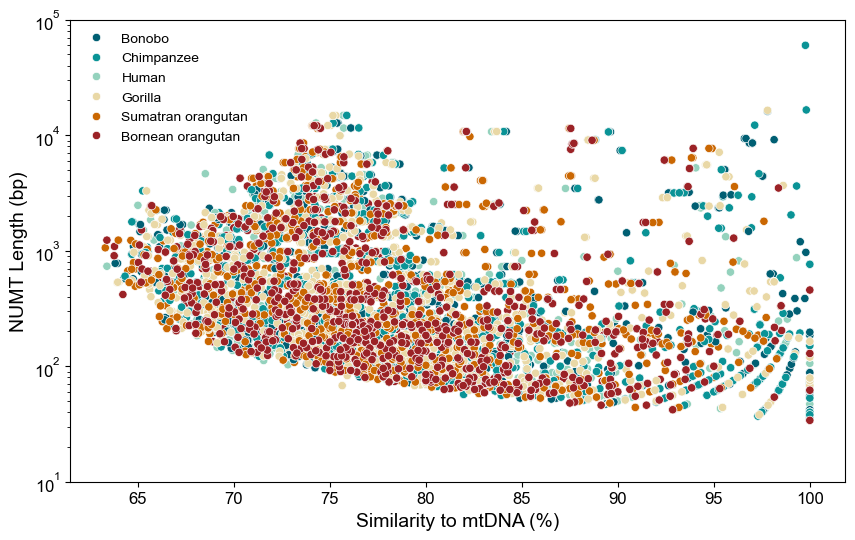

In [8]:
# Extract Identity from the Name column
diploid_numts['Identity'] = diploid_numts['Name'].str.extract(r'identity=([\d\.]+)').astype(float)

fontsize = 14

# Plot using Seaborn
plt.figure(figsize=(10, 6))
sns.scatterplot(data=diploid_numts, x='Identity', y='NUMT_Length', hue='Species', palette=palette7)
plt.yscale('log')
# plt.title('NUMT Length vs Identity')
plt.xlabel('Similarity to mtDNA (%)', size=fontsize)
plt.ylabel('NUMT Length (bp)', size=fontsize)
plt.legend(title='', fontsize=10, frameon=False)
plt.xticks(fontsize=fontsize-2)
plt.yticks(fontsize=fontsize-2)
plt.ylim(10, 10**5)

# Save the plot as PNG and PDF
plt.savefig("plots/numt_identity_vs_length.png", dpi=300, bbox_inches='tight')
plt.savefig("plots/numt_identity_vs_length.pdf", bbox_inches='tight')

In [9]:
diploid_numts['Identity'].describe()

count    8257.000000
mean       79.035634
std         7.785343
min        63.300000
25%        73.617000
50%        77.647000
75%        83.590000
max       100.000000
Name: Identity, dtype: float64